### Step 1 – Read and describe the data


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

survey = pd.read_csv("vehicles.csv", sep="\t")
np.random.seed(42)


### Step 2 – Clean data
* Check which variables have missing values and fill them so the dataset is complete.  
* Use the mean for numeric fields and the most common value (mode) for strings.  
* When you’re done, confirm that no missing values remain.

In [2]:
df_raw = pd.read_csv('vehicles.csv', low_memory=False)
print(df_raw.shape)
df_raw[['year', 'make', 'model', 'VClass', 'fuelType1', 'fuelCost08']].head()
df = df_raw[['year', 'make', 'model', 'VClass', 'fuelType1', 'fuelCost08']].copy()
df = df.dropna()
print(df.shape)
df.head()

(49846, 84)
(49845, 6)


,year,make,model,VClass,fuelType1,fuelCost08
0,1985,Alfa Romeo,Spider Veloce 2000,Two Seaters,Regular Gasoline,2850
1,1985,Ferrari,Testarossa,Two Seaters,Regular Gasoline,5450
2,1985,Dodge,Charger,Subcompact Cars,Regular Gasoline,2200
3,1985,Dodge,B150/B250 Wagon 2WD,Vans,Regular Gasoline,5450
4,1993,Subaru,Legacy AWD Turbo,Compact Cars,Premium Gasoline,3650


In [11]:
df = df_raw.copy()

# Step 1: year filter
df = df[df['year'].between(2015, 2024)]

# Step 2: fuel filter
df = df[df['fuelType1'].isin(['Regular Gasoline', 'Premium Gasoline', 'Midgrade Gasoline', 'Electricity'])]

# Step 3: cost filter
df = df[df['fuelCost08'].notna() & (df['fuelCost08'] > 0)]

# Step 4: fuel category — do this BEFORE class mapping
df['fuel_category'] = df['fuelType1'].apply(lambda x: 'Electric' if x == 'Electricity' else 'Gas')

# Step 5: class mapping
def simplify_class(vclass):
    v = str(vclass).lower()
    if any(x in v for x in ['compact', 'small', 'minicompact', 'subcompact']):
        return 'Compact'
    elif any(x in v for x in ['midsize', 'mid-size']):
        return 'Midsize'
    elif any(x in v for x in ['suv', 'sport utility']):
        return 'SUV'
    elif any(x in v for x in ['truck', 'pickup']):
        return 'Truck'
    elif any(x in v for x in ['large', 'standard']):
        return 'Large'
    else:
        return 'Other'

df['class_simple'] = df['VClass'].apply(simplify_class)
df = df[df['class_simple'] != 'Other']
df = df.rename(columns={'fuelCost08': 'annual_fuel_cost'})

print(df['fuel_category'].value_counts())
print(df['class_simple'].value_counts())

fuel_category
Gas         10810
Electric      711
Name: count, dtype: int64
class_simple
Compact    6016
Midsize    1920
SUV        1674
Large      1070
Truck       841
Name: count, dtype: int64


### Step 3: Formulate your hypothesis

               Count    Mean  Median     Std
fuel_category                               
Electric         711  823.21   800.0  173.03


<Figure size 800x600 with 0 Axes>

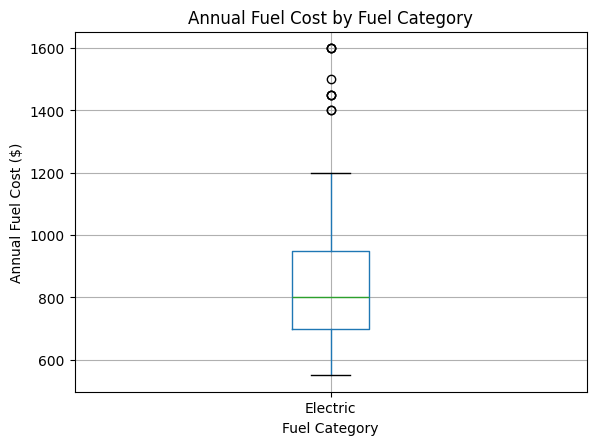

In [6]:
summary = df.groupby('fuel_category')['annual_fuel_cost'].agg(
    Count='count', Mean='mean', Median='median', Std='std'
).round(2)
print(summary)
plt.figure(figsize=(8, 6))
df.boxplot(column='annual_fuel_cost', by='fuel_category')
plt.title('Annual Fuel Cost by Fuel Category')
plt.suptitle('')
plt.xlabel('Fuel Category')
plt.ylabel('Annual Fuel Cost ($)')
plt.show() 


                            Count     Mean  Median
class_simple fuel_category                        
Compact      Electric         279   767.38   750.0
Large        Electric         116   770.26   750.0
Midsize      Electric         117   732.05   700.0
SUV          Electric         150   946.00   900.0
Truck        Electric          49  1108.16  1100.0


<Figure size 1000x600 with 0 Axes>

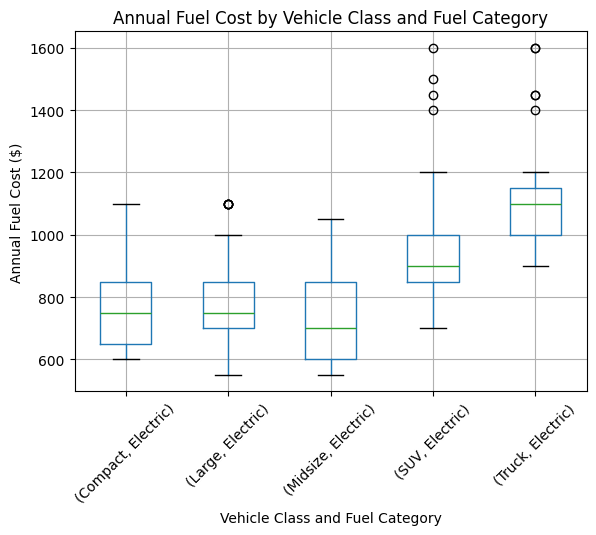

In [7]:
print(df.groupby(['class_simple', 'fuel_category'])['annual_fuel_cost'].agg(
    Count='count', Mean='mean', Median='median'
).round(2))
plt.figure(figsize=(10, 6))
df.boxplot(column='annual_fuel_cost', by=['class_simple', 'fuel_category'])
plt.title('Annual Fuel Cost by Vehicle Class and Fuel Category')
plt.suptitle('')
plt.xlabel('Vehicle Class and Fuel Category')
plt.ylabel('Annual Fuel Cost ($)')
plt.xticks(rotation=45)
plt.show()



### Step 4: Identify at least one metric for bootstrap uncertainty

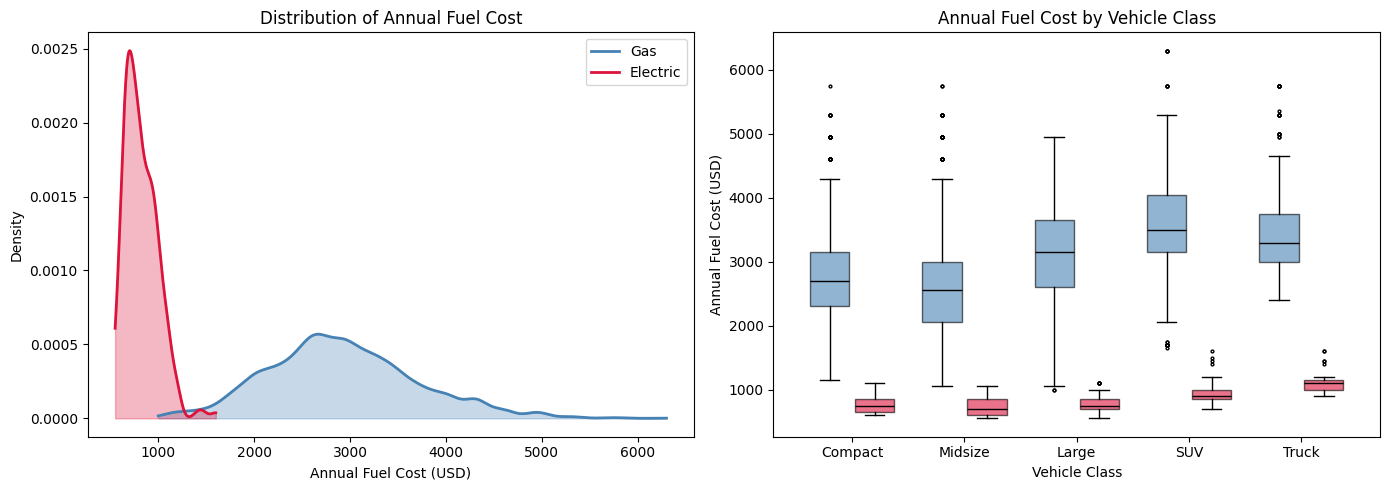

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram — density=True normalizes both groups to the same scale
import numpy as np
ax = axes[0]
for label, color in [('Gas', 'steelblue'), ('Electric', 'crimson')]:
    subset = df[df['fuel_category'] == label]['annual_fuel_cost'].values
    from scipy.stats import gaussian_kde
    kde = gaussian_kde(subset)
    x = np.linspace(subset.min(), subset.max(), 300)
    ax.plot(x, kde(x), color=color, linewidth=2, label=label)
    ax.fill_between(x, kde(x), alpha=0.3, color=color)
ax.set_title('Distribution of Annual Fuel Cost')
ax.set_xlabel('Annual Fuel Cost (USD)')
ax.set_ylabel('Density')
ax.legend()

# Boxplot by class
ax2 = axes[1]
class_order = [c for c in ['Compact', 'Midsize', 'Large', 'SUV', 'Truck'] if c in df['class_simple'].unique()]
for label, color in [('Gas', 'steelblue'), ('Electric', 'crimson')]:
    subset = df[df['fuel_category'] == label]
    positions = [i + (0.2 if label == 'Electric' else -0.2) for i in range(len(class_order))]
    data = [subset[subset['class_simple'] == c]['annual_fuel_cost'].values for c in class_order]
    bp = ax2.boxplot(data, positions=positions, widths=0.35, patch_artist=True,
                     boxprops=dict(facecolor=color, alpha=0.6),
                     medianprops=dict(color='black'), flierprops=dict(markersize=2))
ax2.set_xticks(range(len(class_order)))
ax2.set_xticklabels(class_order)
ax2.set_title('Annual Fuel Cost by Vehicle Class')
ax2.set_xlabel('Vehicle Class')
ax2.set_ylabel('Annual Fuel Cost (USD)')

plt.tight_layout()
plt.show() 



In [17]:
ev  = df[df['fuel_category'] == 'Electric']['annual_fuel_cost'].values
gas = df[df['fuel_category'] == 'Gas']['annual_fuel_cost'].values

obs_diff = gas.mean() - ev.mean()
print(f"Mean annual cost — Gas:      ${gas.mean():,.2f}")
print(f"Mean annual cost — Electric: ${ev.mean():,.2f}")
print(f"Observed difference:         ${obs_diff:,.2f}")


Mean annual cost — Gas:      $2,920.71
Mean annual cost — Electric: $823.21
Observed difference:         $2,097.51


In [ ]:
perm = 10000
combined = np.concatenate([gas, ev])
gas = len(gas)

permdiffs = np.array([
    np.random.permutation(combined)[:gas].mean() -
    np.random.permutation(combined)[gas:].mean()
    for _ in range(perm)
])

p_value = np.mean(permdiffs >= obs_diff)
print(f"p-value (one-tailed): {p_value:.4f}")
if p_value == 0:
    print("Reported as: p < 0.001")


p-value (one-tailed): 0.0000
Reported as: p < 0.001


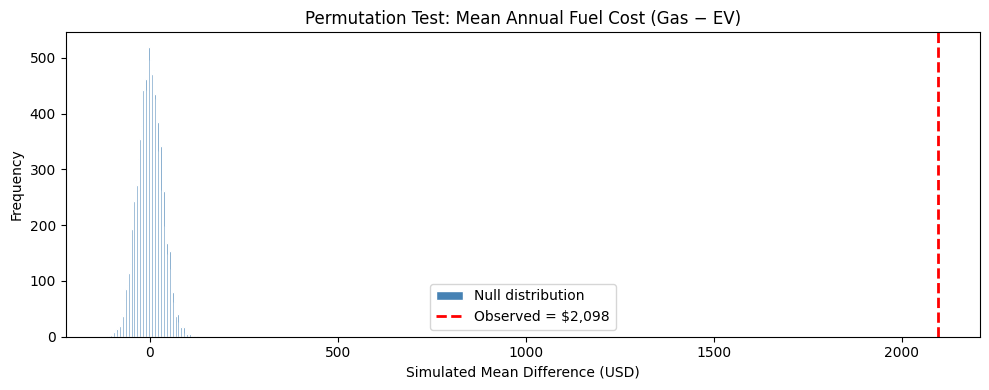

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(permdiffs, bins=60, color='steelblue', edgecolor='white', label='Null distribution')
plt.axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label=f'Observed = ${obs_diff:,.0f}')
plt.title('Permutation Test: Mean Annual Fuel Cost (Gas − EV)')
plt.xlabel('Simulated Mean Difference (USD)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()



## 7. Bootstrap Confidence Intervals

**Metric 1 — Mean annual fuel cost difference (Gas − EV):**  
The CLT could apply to means with large samples, but we bootstrap for consistency.

**Metric 2 — Median annual fuel cost per group:**  
The CLT does **not** apply to medians. The sampling distribution of the median depends on the density of the population at the median, and has no simple closed-form standard error — especially in a right-skewed distribution like fuel costs. Bootstrapping is the appropriate method here.


In [21]:
BOOT = 10000

# Metric 1: mean difference
boot_mean_diffs = np.array([
    np.random.choice(gas, size=len(gas), replace=True).mean() -
    np.random.choice(ev,  size=len(ev),  replace=True).mean()
    for _ in range(BOOT)
])
ci_mean = np.percentile(boot_mean_diffs, [2.5, 97.5])

print(" Metric 1: Mean Annual Cost Difference (Gas − EV)")
print(f"  Observed: ${obs_diff:,.2f}")
print(f"  95% CI:   (${ci_mean[0]:,.2f}, ${ci_mean[1]:,.2f})")


 Metric 1: Mean Annual Cost Difference (Gas − EV)
  Observed: $2,097.51
  95% CI:   ($2,078.54, $2,116.82)


In [23]:
# Metric 2: median per group
boot_med_gas = np.array([np.median(np.random.choice(gas, size=len(gas), replace=True)) for _ in range(BOOT)])
boot_med_ev  = np.array([np.median(np.random.choice(ev,  size=len(ev),  replace=True)) for _ in range(BOOT)])

ci_med_gas = np.percentile(boot_med_gas, [2.5, 97.5])
ci_med_ev  = np.percentile(boot_med_ev,  [2.5, 97.5])

print("=== Metric 2: Median Annual Fuel Cost ===")
print(f"  Gas — Observed: ${np.median(gas):,.2f}  |  95% CI: (${ci_med_gas[0]:,.2f}, ${ci_med_gas[1]:,.2f})")
print(f"  EV  — Observed: ${np.median(ev):,.2f}   |  95% CI: (${ci_med_ev[0]:,.2f},  ${ci_med_ev[1]:,.2f})")


=== Metric 2: Median Annual Fuel Cost ===
  Gas — Observed: $2,850.00  |  95% CI: ($2,850.00, $2,900.00)
  EV  — Observed: $800.00   |  95% CI: ($800.00,  $800.00)


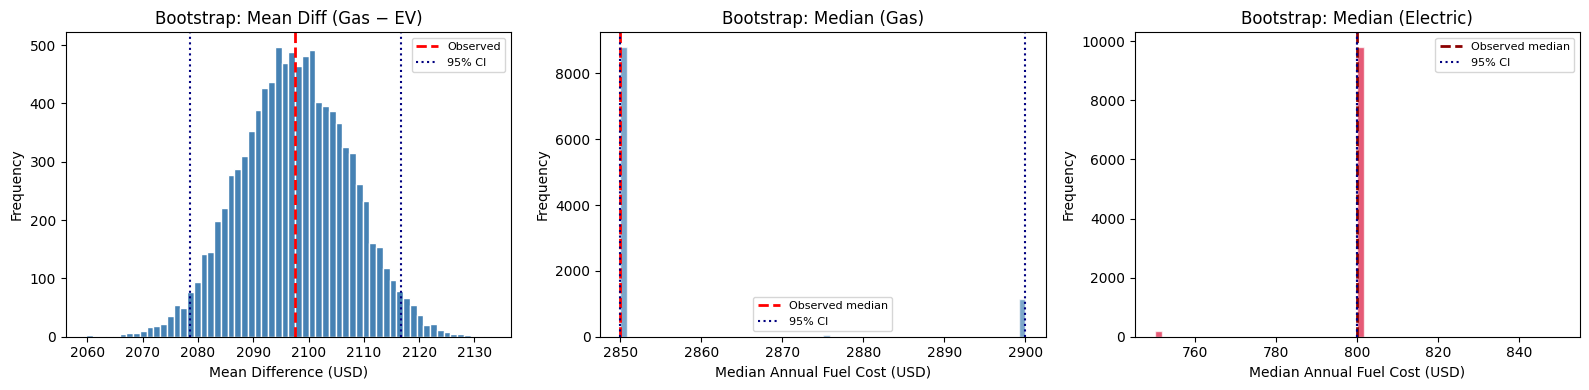

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Mean difference
axes[0].hist(boot_mean_diffs, bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(obs_diff, color='red', linestyle='dashed', linewidth=2, label='Observed')
axes[0].axvline(ci_mean[0], color='navy', linestyle=':', linewidth=1.5, label='95% CI')
axes[0].axvline(ci_mean[1], color='navy', linestyle=':', linewidth=1.5)
axes[0].set_title('Bootstrap: Mean Diff (Gas − EV)')
axes[0].set_xlabel('Mean Difference (USD)')
axes[0].set_ylabel('Frequency')
axes[0].legend(fontsize=8)

# Median Gas
axes[1].hist(boot_med_gas, bins=60, color='steelblue', alpha=0.7, edgecolor='white')
axes[1].axvline(np.median(gas), color='red', linestyle='dashed', linewidth=2, label='Observed median')
axes[1].axvline(ci_med_gas[0], color='navy', linestyle=':', linewidth=1.5, label='95% CI')
axes[1].axvline(ci_med_gas[1], color='navy', linestyle=':', linewidth=1.5)
axes[1].set_title('Bootstrap: Median (Gas)')
axes[1].set_xlabel('Median Annual Fuel Cost (USD)')
axes[1].set_ylabel('Frequency')
axes[1].legend(fontsize=8)

# Median EV
axes[2].hist(boot_med_ev, bins=60, color='crimson', alpha=0.7, edgecolor='white')
axes[2].axvline(np.median(ev), color='darkred', linestyle='dashed', linewidth=2, label='Observed median')
axes[2].axvline(ci_med_ev[0], color='navy', linestyle=':', linewidth=1.5, label='95% CI')
axes[2].axvline(ci_med_ev[1], color='navy', linestyle=':', linewidth=1.5)
axes[2].set_title('Bootstrap: Median (Electric)')
axes[2].set_xlabel('Median Annual Fuel Cost (USD)')
axes[2].set_ylabel('Frequency')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [27]:
print("RESULTS SUMMARY")
print(f"\nPermutation Test")
print(f"  Observed difference (Gas − EV): ${obs_diff:,.2f}/year")
print(f"  p-value: {p_value:.4f}")
if p_value < 0.05:
    print("  Conclusion: Reject null — gas costs significantly more.")
else:
    print("  Conclusion: Cannot reject null.")

print(f"\nBootstrap CI — Mean Difference")
print(f"  95% CI: (${ci_mean[0]:,.2f}, ${ci_mean[1]:,.2f})")

print(f"\nBootstrap CI — Median Annual Fuel Cost")
print(f"  Gas: ${np.median(gas):,.2f}  (95% CI: ${ci_med_gas[0]:,.2f}–${ci_med_gas[1]:,.2f})")
print(f"  EV:  ${np.median(ev):,.2f}   (95% CI: ${ci_med_ev[0]:,.2f}–${ci_med_ev[1]:,.2f})")


RESULTS SUMMARY

Permutation Test
  Observed difference (Gas − EV): $2,097.51/year
  p-value: 0.0000
  Conclusion: Reject null — gas costs significantly more.

Bootstrap CI — Mean Difference
  95% CI: ($2,078.54, $2,116.82)

Bootstrap CI — Median Annual Fuel Cost
  Gas: $2,850.00  (95% CI: $2,850.00–$2,900.00)
  EV:  $800.00   (95% CI: $800.00–$800.00)


## 9. Mapping to the Only One Test Framework

| Element | In this example |
|---|---|
| **Data** | EPA FuelEconomy.gov `vehicles.csv`, filtered to 2015–2024 model years, Electricity and Gasoline fuel types only. Each row is one vehicle configuration. |
| **Test statistic** | Mean annual fuel cost of gas vehicles minus mean annual fuel cost of EVs. |
| **Observed value** | $2,097.51/year  (fill in after running) |
| **Null hypothesis** | Fuel type has no effect on annual cost. Shuffling the Electric/Gas labels should produce differences as large as the observed one fairly often. |
| **How you simulate under the null** | Randomly shuffle the `fuel_category` labels 10,000 times. After each shuffle, recompute the mean cost difference between the two randomly assigned groups. |
| **Reference distribution** | 10,000 simulated mean differences, centered near zero, showing what differences arise purely by chance. |
| **p-value** | Fraction of simulated differences at least as large as the observed difference. |

---

## 10. Limitations

- Annual fuel cost is EPA-estimated, not observed. It assumes 15,000 mi/yr and fixed fuel prices from the label year, so individual costs will vary.
- Fuel prices changed a lot between 2015 and 2024. Older model years reflect older gas prices.
- This is fuel cost only — not total cost of ownership. EVs tend to have higher purchase prices and lower maintenance costs.
- There are far more gas vehicle configurations than EV configurations in the dataset, especially for trucks, so class-level EV estimates may be noisier.
